In [12]:
import json
import pickle
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd

from aare_train.evaluation.eval_metric import EvalMetric
from aare_train.evaluation.forecast_samples import ForecastSamples
from aare_train.paths import METRICS_FOLDER, FORECAST_SAMPLES_FOLDER

plt.rcParams["figure.figsize"] = (16, 9)

# Baseline showcase

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
def plot_from_file(path, title: str):
    with open(path, "rb") as file:
        sample = cast(ForecastSamples, pickle.load(file))

    print(type(sample))

    return sample.plot(title)

In [15]:
def plot_baseline(model: str):
    plot_from_file(FORECAST_SAMPLES_FOLDER / f"{model}.pkl", model)

In [16]:
def read_metrics(path, as_dict=False):
    with open(path, "rt") as file:
        raw = json.load(file)
        if as_dict:
            return raw

        return EvalMetric.from_dict(raw)

In [17]:
def combine_metrics(*models: str):
    metrics = []
    for model in models:
        metrics.append(read_metrics(METRICS_FOLDER / f"{model}.json", as_dict=True) | dict(name=model))

    return pd.DataFrame(metrics).set_index("name")

These are the aggregate metrics for each baseline model over the entire validation period using a strided evaluation (see params.yaml for stride). The mae and rmse values are the median of all the forecasts the model has made for the validation period.

In [18]:
combine_metrics("LOCF", "MEAN", "SNAIVE", "TIMESFM")

,mae,rmse,madpd,mae_std,rmse_std,madpd_std
name,,,,,,
LOCF,1.131293,1.329747,1.629167,0.664300,0.705276,1.000742
MEAN,1.187173,1.408428,1.414310,0.621005,0.644330,0.946362
SNAIVE,1.025035,1.209660,1.025660,0.633515,0.700871,0.671927
TIMESFM,0.863621,1.022403,0.893926,0.607108,0.683050,0.625074


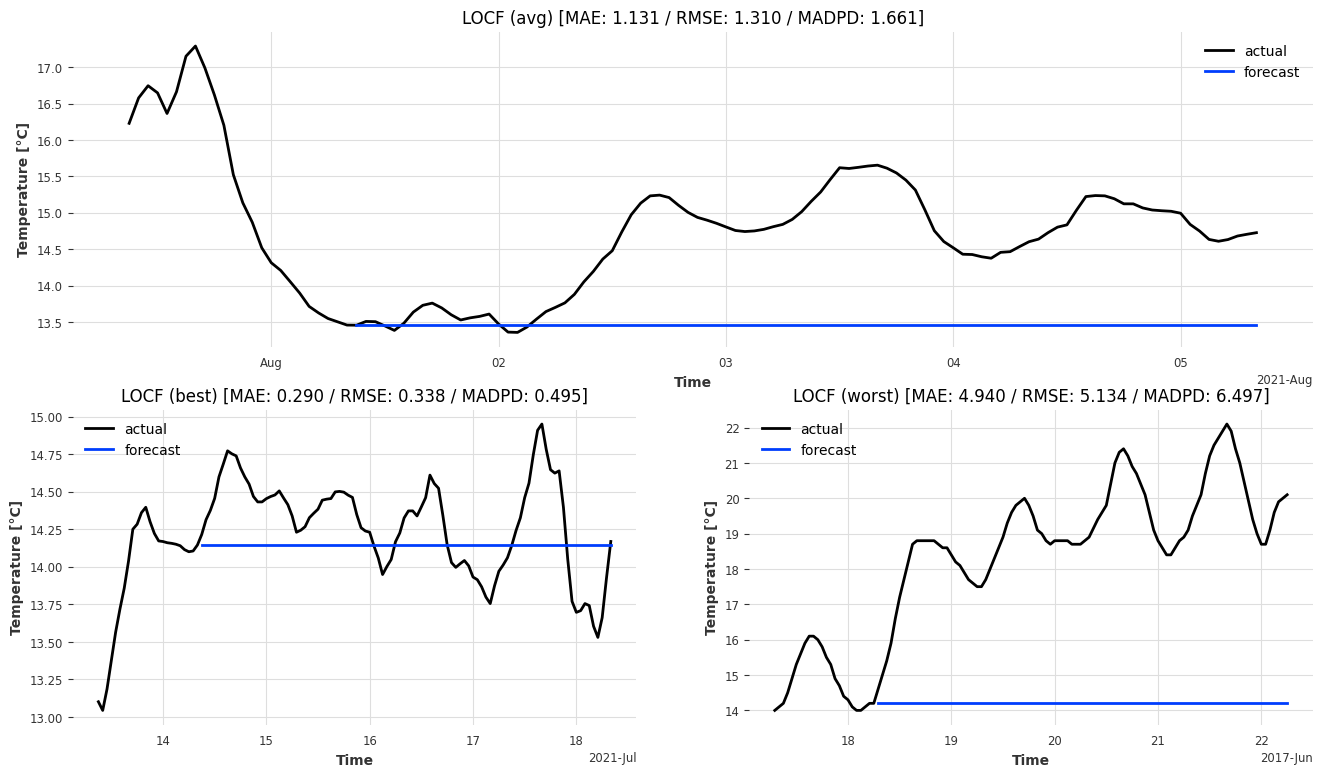

In [19]:
plot_baseline("LOCF")

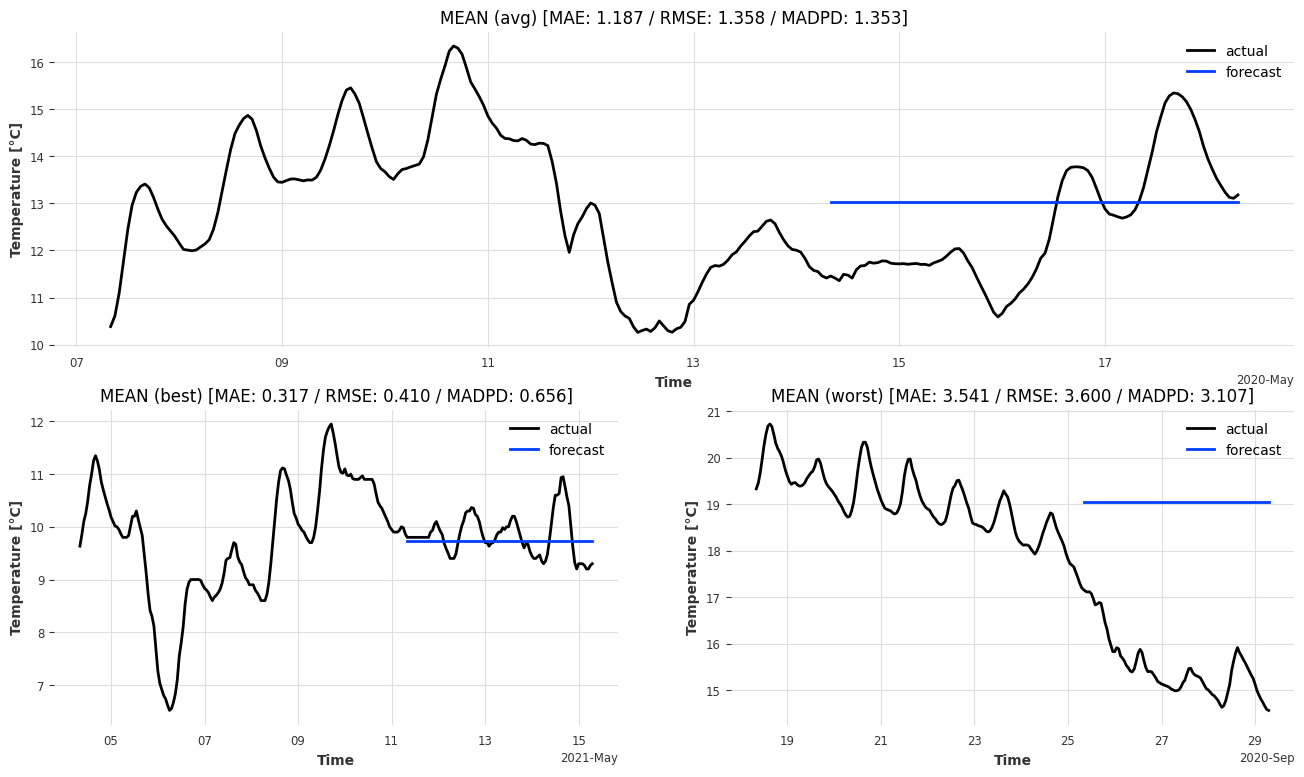

In [20]:
plot_baseline("MEAN")

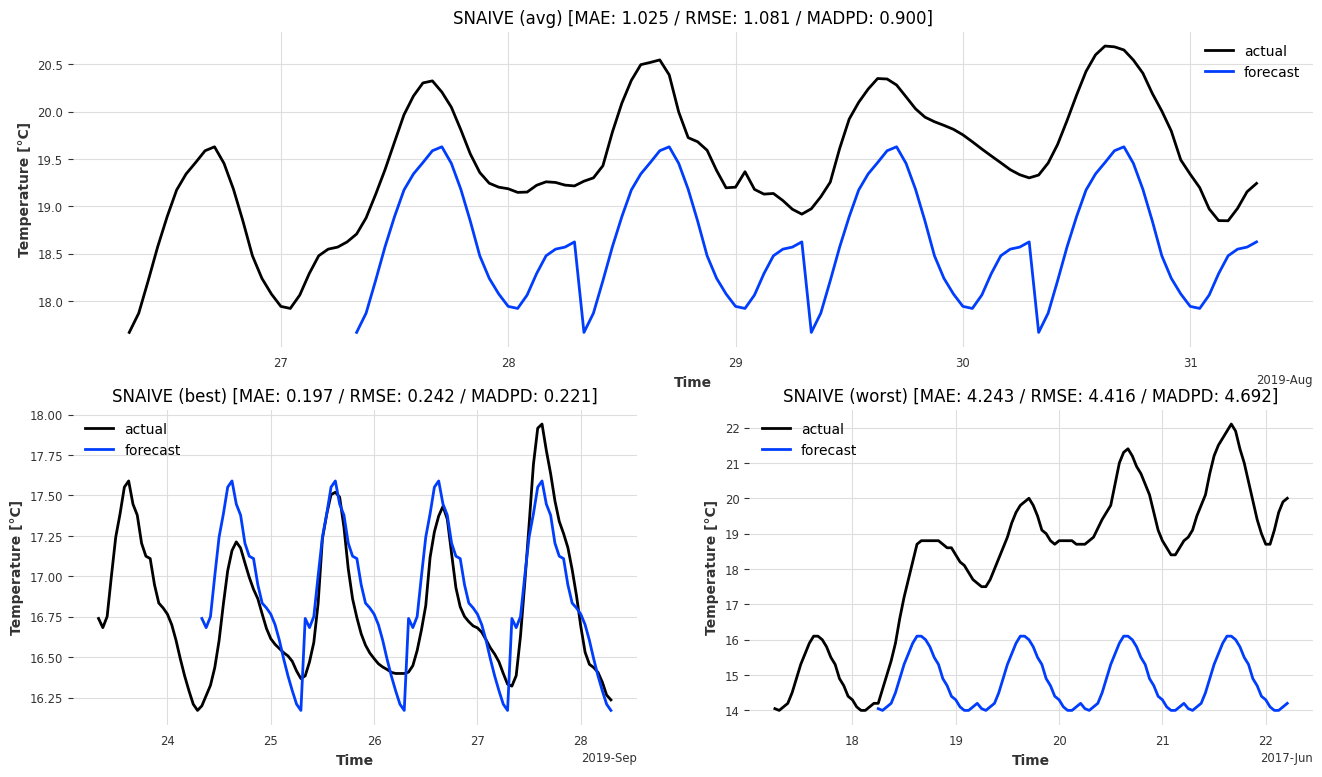

In [21]:
plot_baseline("SNAIVE")

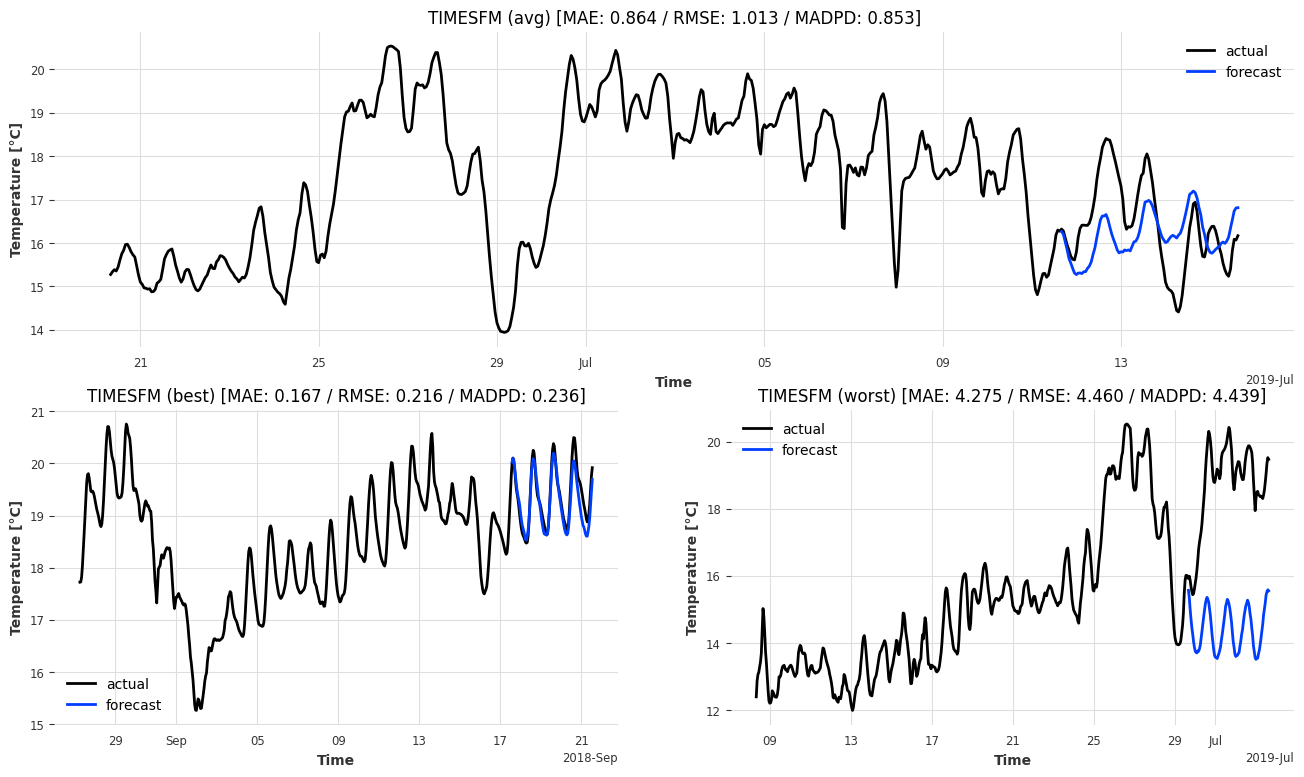

In [22]:
plot_baseline("TIMESFM")